In [2]:
import glob
import os
import re
from typing import List, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid", context="talk")

In [4]:
def get_folder_paths(folder_path, folder_pattern):
    # Важно: убедимся, что folder_path заканчивается слешем, иначе конкатенация склеит пути неправильно
    if not folder_path.endswith(os.sep):
        folder_path += os.sep
        
    folder_list = [folder_path + f for f in os.listdir(folder_path) 
                   if os.path.isdir(os.path.join(folder_path, f)) and re.search(folder_pattern, f)]
    folder_list.sort(key=os.path.getctime)
    return folder_list

def extract_number(filename):
    # Извлекаем число N из C[N]-avg-.plt
    match = re.search(r'C\[(\d+)\]-avg-\.plt', filename)
    return int(match.group(1)) if match else float('inf') 

def sort_filenames(filenames):
    return sorted(filenames, key=extract_number)

def get_filenames(file_path, file_pattern):
    file_list = [f for f in os.listdir(file_path) 
                 if os.path.isfile(os.path.join(file_path, f)) and re.search(file_pattern, f)]
    file_list = sort_filenames(file_list)
    return file_list

In [5]:
def read_tecplot_slice(full_path: str, z_index: int) -> pd.DataFrame:
    """
    Читает Tecplot файл, находит нужную высоту Z и формирует матрицу для heatmap.
    """
    header_rows = 0
    var_name = "Concentration"

    # 1. Парсим заголовок (ищем имя переменной и начало данных)
    with open(full_path, 'r') as f:
        for i, line in enumerate(f):
            line = line.strip()
            if line.startswith('VARIABLES'):
                # Пытаемся вытащить имя переменной, например "C[21]"
                parts = re.findall(r'"(.*?)"', line)
                if len(parts) >= 4:
                    var_name = parts[3]
            
            # Эвристика: данные начинаются с числа или знака минус
            if line and (line[0].isdigit() or line[0] == '-'):
                header_rows = i
                break
    
    # 2. Читаем данные в DataFrame
    df = pd.read_csv(
        full_path,
        skiprows=header_rows,
        sep=r'\s+',
        names=['X', 'Y', 'Z', 'Value'],
        engine='c'
    )

    # 3. Фильтрация по высоте
    unique_zs = sorted(df['Z'].unique())
    if z_index >= len(unique_zs):
        raise ValueError(f"Z index {z_index} out of bounds. Max index: {len(unique_zs)-1}")
    
    target_z = unique_zs[z_index]
    
    # Оставляем только нужный срез
    slice_df = df[np.isclose(df['Z'], target_z)].copy()
    
    # 4. Обработка 'nodata' (-9999 -> NaN)
    slice_df.loc[slice_df['Value'] <= -9000, 'Value'] = np.nan

    # 5. Пивот таблицы (X, Y -> Matrix)
    # Сортируем Y по убыванию, чтобы график не был перевернут
    pivot_data = slice_df.pivot(index='Y', columns='X', values='Value').sort_index(ascending=False)
    
    return pivot_data, var_name, target_z


In [6]:
def plot_heatmap(pivot_data, var_name, z_height, filename):
    """
    Отрисовка карты концентрации через Seaborn.
    """
    plt.figure(figsize=(10, 8))
    
    ax = sns.heatmap(
        pivot_data,
        cmap="turbo",       # Контрастная палитра
        square=True,        # Квадратные ячейки
        cbar_kws={'label': var_name},
        xticklabels=10,     # Прореживание подписей осей
        yticklabels=10,
        mask=pivot_data.isnull() # Явная маска для NaN
    )
    
    # Серый фон для зданий (NaN значений)
    ax.set_facecolor("lightgray")
    
    plt.title(f"File: {filename}\nVariable: {var_name} | Height Z ≈ {z_height:.2f}", fontsize=14)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.tight_layout()
    plt.show()

Selected build: /app/urban-layer/build_cuda1222_scale
Selected output dir: /app/urban-layer/build_cuda1222_scale/output_2026_1_11_14_14_18
Found 32 files. Sorted: ['C[0]-avg-.plt', 'C[1]-avg-.plt', 'C[2]-avg-.plt', 'C[3]-avg-.plt', 'C[4]-avg-.plt', 'C[5]-avg-.plt', 'C[6]-avg-.plt', 'C[7]-avg-.plt', 'C[8]-avg-.plt', 'C[9]-avg-.plt', 'C[10]-avg-.plt', 'C[11]-avg-.plt', 'C[12]-avg-.plt', 'C[13]-avg-.plt', 'C[14]-avg-.plt', 'C[15]-avg-.plt', 'C[16]-avg-.plt', 'C[17]-avg-.plt', 'C[18]-avg-.plt', 'C[19]-avg-.plt', 'C[20]-avg-.plt', 'C[21]-avg-.plt', 'C[22]-avg-.plt', 'C[23]-avg-.plt', 'C[24]-avg-.plt', 'C[25]-avg-.plt', 'C[26]-avg-.plt', 'C[27]-avg-.plt', 'C[28]-avg-.plt', 'C[29]-avg-.plt', 'C[30]-avg-.plt', 'C[31]-avg-.plt']
Plotting C[0]-avg-.plt at level 0...


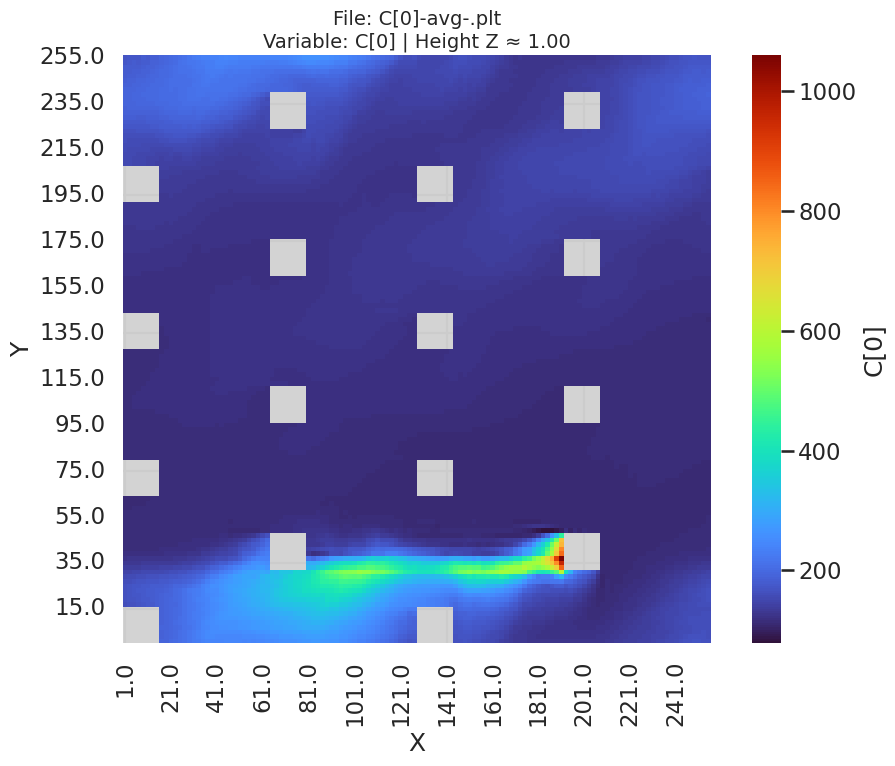

In [8]:
base_path = '/app/urban-layer/'
    
# 1. Ищем папки build*
build_folders = get_folder_paths(base_path, r'build_cuda1222_scale$')

if not build_folders:
    print(f"No build folders found in {base_path}")

# Берем последний созданный build (так как get_folder_paths сортирует по getctime)
last_build = build_folders[-1]
print(f"Selected build: {last_build}")

# 2. Ищем папки output_* внутри выбранного build
output_folders = get_folder_paths(last_build, r'output_.*')

if not output_folders:
    print(f"No output folders found in {last_build}")
    
# Берем последнюю output папку (или можно перебрать все)
target_output_dir = output_folders[0]
print(f"Selected output dir: {target_output_dir}")

# 3. Ищем файлы C[...]-avg-.plt внутри output
# Регулярка для файла: начинается на C, потом число в скобках, потом -avg-.plt
file_pattern = r'C\[\d+\]-avg-\.plt'

files = get_filenames(target_output_dir + '/stat-3d/', file_pattern)

if not files:
    print(f"No concentration files found in {target_output_dir}")

print(f"Found {len(files)} files. Sorted: {files}")

# 4. Выбираем файл для отрисовки (например, первый и последний)
# Пример: отрисуем C[1] и C[21] (если есть)
files_to_plot = [files[0]]
# if len(files) > 1:
#     files_to_plot.append(files[-1])

for filename in files_to_plot:
    full_path = os.path.join(target_output_dir + '/stat-3d/', filename)
    
    # Выбираем уровень высоты (z_index).
    # 0 = земля, 5 = повыше.
    z_level_index = 0
        
    try:
        print(f"Plotting {filename} at level {z_level_index}...")
        pivot_data, var_name, z_val = read_tecplot_slice(full_path, z_level_index)
        plot_heatmap(pivot_data, var_name, z_val, filename)
    except Exception as e:
        print(f"Error plotting {filename}: {e}")